# Complementarily of GW and GRB Observations in Constraining Cosmological Parameters

# Multi-Messenger Breaks Degeneracies

A single probe alone exhibits degeneracies between cosmological parameters. That is because changing two parameters proportionally turn into the same result. However, this can be sovled with multi-messenger astronomy, and that is one of the reasons why it is so powerful.

**Can we predict how the degeneracy will look like in an $\Omega_m - \Omega_\Lambda$ or $\Omega_m - H_0$ contour plot?**

The orientation of an error ellipse in any parameter space is given by the ratio of how sensitive the observable is to those parameters. Meaning, we have look at the Fisher Information Matrix (FIM) and compute the sensitivity for a distance modulus $\mu (z, \theta_i)$:
$$\frac{∂ \mu}{∂ \theta_i}$$

## Orthogonality in the $\Omega_m - H_=$ plane
The distance modulus is defined by
$$
\mu (z) = 5 \log_10 \left(\frac{(1+z)c}{H_0} \int_0 ^z \frac{dz^\prime}{E(z^\prime)} \right) + 25
$$

Then the partial derivatives are
$$
\frac{\partial \mu}{\partial H_0} = - \frac{5}{H_0\ln(10)}
$$
$$
\frac{\partial \mu}{\partial \Omega_m} \propto \frac{\partial}{\partial \Omega_m} \left(\int_0 ^z \frac{dz^\prime}{\sqrt{\Omega_m (1+z^\prime)^3 + ...}}\right)
$$

Notice how the second derivative is dependant on redshift while the first not. In turns this means:

* GWs: at low redshift $\frac{\partial \mu}{\partial H_0}$ is relatively large in comparison with $\frac{\partial \mu}{\partial \Omega_m} \approx 0$.
* GRBs: at high redshift $(z>1)$, the evaluation of the integral grows rapidly becoming greater than the partial derivative of $H_0$.

For our contours in a $H_0 \Omega_m$ plane that means that the GW contours are primarily horizontal while the GRBs mainly vertical, hinting at the preferred region in the crossing.

## Orthogonality in the $\Omega_m - \Omega_\Lambda$ plane

Let's assume that $H_0$ is perfecty known, then the sensitivity is entirely governed by the integral of the Hubble parameter:
$$
I(z) = \int_0 ^z \frac{dz^\prime}{\sqrt{\Omega_m(1+z^\prime)^3 + \Omega_\Lambda}}
$$

* GW: at low redshift $(1+z)^3$ is of the order unity. For example, let $z=0.1$, then $(1+z)^3 = 1.33$ which is relatively similar weight to $\Omega_\Lambda$. This creates a highly correlated degeneracy.
* GRBs: at high redshift, the matter term explodes while the dark energy parameter has a constant weight $1$. For example, letting $z=3$ results in $(1+z)^3 = 64$.

In the next cells we illustrate that with simulated data.

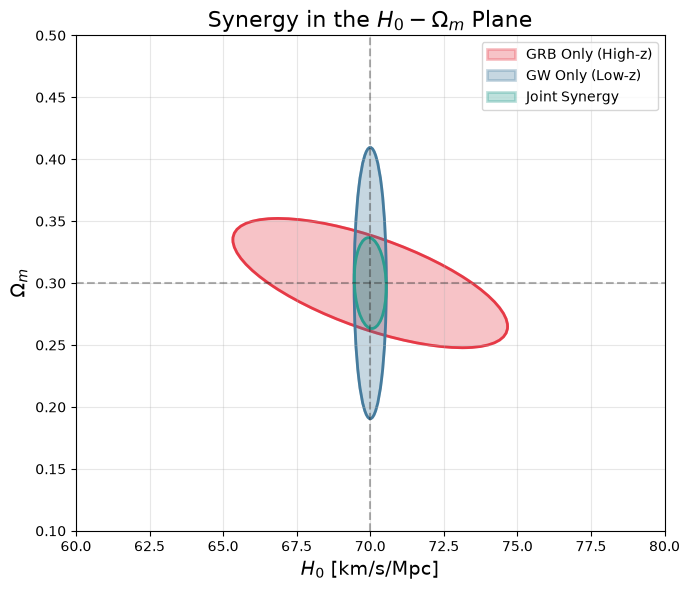

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(ax, F, center, color, label):
    """Inverts Fisher Matrix to get Covariance and plots the 95% Error Ellipse."""
    Cov = np.linalg.inv(F)
    eigenvalues, eigenvectors = np.linalg.eigh(Cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(5.991 * eigenvalues) # 5.991 is for 95% Confidence Level
    
    ell = Ellipse(xy=center, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, lw=2, alpha=0.3, label=label)
    ax.add_patch(ell)
    ax.add_patch(Ellipse(xy=center, width=width, height=height, angle=angle,
                         edgecolor=color, facecolor='none', lw=2))

# Fiducial Values
H0_true = 70.0
Om_true = 0.3

# --- Simulated Fisher Matrices ---
# GWs: Massive information on H0, practically zero on Om. No cross-term.
F_GW = np.array([[20.0, 0.0], 
                 [0.0,  500.0]])

# GRBs: Good information on Om, but highly degenerate with H0 (strong cross-term).
F_GRB = np.array([[0.5, 30.0], 
                  [30.0, 4000.0]])

# Joint Synergy
F_Joint = F_GW + F_GRB

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 6))
draw_ellipse(ax, F_GRB, (H0_true, Om_true), '#e63946', 'GRB Only (High-z)')
draw_ellipse(ax, F_GW, (H0_true, Om_true), '#457b9d', 'GW Only (Low-z)')
draw_ellipse(ax, F_Joint, (H0_true, Om_true), '#2a9d8f', 'Joint Synergy')

ax.set_xlim(60, 80)
ax.set_ylim(0.1, 0.5)
ax.set_xlabel(r'$H_0$ [km/s/Mpc]', fontsize=14)
ax.set_ylabel(r'$\Omega_m$', fontsize=14)
ax.set_title(r"Synergy in the $H_0 - \Omega_m$ Plane", fontsize=16)
ax.axvline(H0_true, color='k', ls='--', alpha=0.3)
ax.axhline(Om_true, color='k', ls='--', alpha=0.3)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig.savefig("complementarity.pdf")

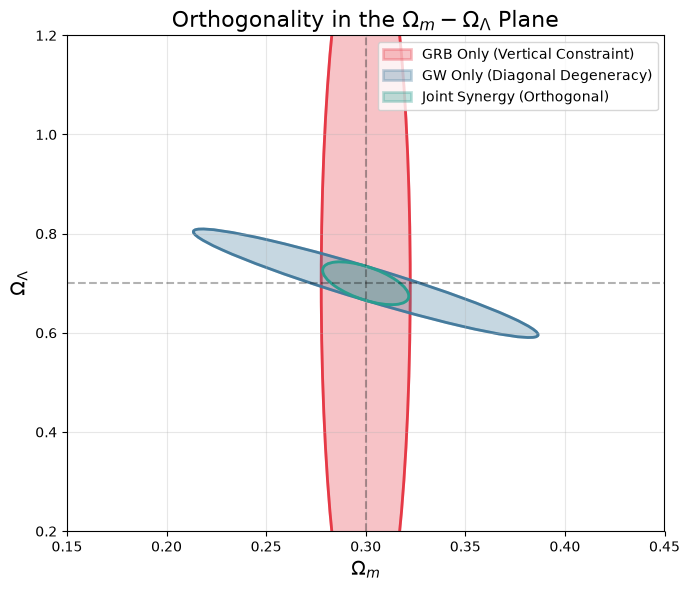

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_ellipse(ax, F, center, color, label):
    Cov = np.linalg.inv(F)
    eigenvalues, eigenvectors = np.linalg.eigh(Cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(5.991 * eigenvalues) 
    
    ell = Ellipse(xy=center, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, lw=2, alpha=0.3, label=label)
    ax.add_patch(ell)
    ax.add_patch(Ellipse(xy=center, width=width, height=height, angle=angle,
                         edgecolor=color, facecolor='none', lw=2))

# Fiducial Values (Flat LambdaCDM)
Om_true = 0.3
OL_true = 0.7

# --- Simulated Fisher Matrices ---
# GWs (Low-z): Degeneracy between Om and OL. If Om goes up, OL must go up to maintain distance.
F_GW = np.array([[8000, 6000], 
                 [6000, 5000]])

# GRBs (High-z): Huge information on Om, zero information on OL.
F_GRB = np.array([[12000, 0], 
                  [0,    10]])

F_Joint = F_GW + F_GRB

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 6))
draw_ellipse(ax, F_GRB, (Om_true, OL_true), '#e63946', 'GRB Only (Vertical Constraint)')
draw_ellipse(ax, F_GW, (Om_true, OL_true), '#457b9d', 'GW Only (Diagonal Degeneracy)')
draw_ellipse(ax, F_Joint, (Om_true, OL_true), '#2a9d8f', 'Joint Synergy (Orthogonal)')

ax.set_xlim(0.15, 0.45)
ax.set_ylim(0.2, 1.2)
ax.set_xlabel(r'$\Omega_m$', fontsize=14)
ax.set_ylabel(r'$\Omega_\Lambda$', fontsize=14)
ax.set_title(r"Orthogonality in the $\Omega_m - \Omega_\Lambda$ Plane", fontsize=16)
ax.axvline(Om_true, color='k', ls='--', alpha=0.3)
ax.axhline(OL_true, color='k', ls='--', alpha=0.3)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

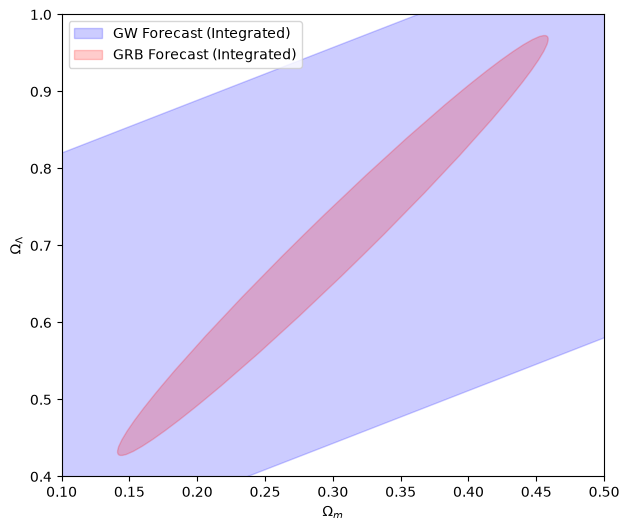

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from matplotlib.patches import Ellipse

# --- Constants & Settings ---
c = 299792.458  # km/s
H0 = 70.0

def E(z, Om, OL):
    """Dimensionless Hubble Parameter for LambdaCDM."""
    return np.sqrt(Om * (1 + z)**3 + (1 - Om - OL) * (1 + z)**2 + OL)

def dist_modulus(z, Om, OL):
    """Calculates mu(z) via numerical integration of 1/E(z)."""
    integral, _ = quad(lambda zp: 1.0 / E(zp, Om, OL), 0, z)
    dl = (c * (1 + z) / H0) * integral
    return 5 * np.log10(dl) + 25

def compute_fisher(z_array, sigma_mu, Om_fid, OL_fid):
    """Computes the 2x2 Fisher Matrix using numerical derivatives."""
    F = np.zeros((2, 2))
    eps = 1e-4  # Step for numerical derivative
    
    for z in z_array:
        # Partial derivatives via central difference
        dmu_dOm = (dist_modulus(z, Om_fid + eps, OL_fid) - dist_modulus(z, Om_fid - eps, OL_fid)) / (2 * eps)
        dmu_dOL = (dist_modulus(z, Om_fid, OL_fid + eps) - dist_modulus(z, Om_fid, OL_fid - eps)) / (2 * eps)
        
        derivs = np.array([dmu_dOm, dmu_dOL])
        F += (1.0 / sigma_mu**2) * np.outer(derivs, derivs)
    return F

# --- Simulation ---
z_gw = np.linspace(0.01, 0.5, 50)   # 50 Low-z Standard Sirens
z_grb = np.linspace(1.0, 6.0, 150)  # 150 High-z GRBs
sig_mu = 0.2  # Magnitude uncertainty

F_GW = compute_fisher(z_gw, sig_mu, 0.3, 0.7)
F_GRB = compute_fisher(z_grb, sig_mu, 0.3, 0.7)

# --- Plotting (Reuse earlier ellipse logic) ---
def plot_fisher(ax, F, center, color, label):
    cov = np.linalg.inv(F)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    v, w = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*w[:, 0][::-1]))
    width, height = 2 * np.sqrt(5.991 * v)
    ell = Ellipse(xy=center, width=width, height=height, angle=theta,
                  edgecolor=color, fc=color, alpha=0.2, label=label)
    ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(7, 6))
plot_fisher(ax, F_GW, (0.3, 0.7), 'blue', 'GW Forecast (Integrated)')
plot_fisher(ax, F_GRB, (0.3, 0.7), 'red', 'GRB Forecast (Integrated)')
ax.set_xlim(0.1, 0.5); ax.set_ylim(0.4, 1.0)
ax.set_xlabel(r"$\Omega_m$"); ax.set_ylabel(r"$\Omega_\Lambda$")
ax.legend(); plt.show()

# Degeneracies in the $w_0 w_a$CDM model

If we want to test altertive models like the proposed $w_0w_a$CDM model in which dark energy is non a cosmological constant $(\Lambda)$ but time-dependent.

In this case, the degeneracies in the $H_0 - \Omega_m$ plane, and the $H_0 - \Omega_\Lambda$ plane identical, since $H_0$ is constant for redshift. With that is is meant that the measurement of th $H_0$ is constant independently of the redshift of the observed phenomena, the Hubble Parameter $H(t)$ however is not constant in time.

Anyways, the $\Omega_m - \Omega_\Lambda$ from $\Lambda$CDM turns into an $\Omega_m - \Omega_{de}$ plane where the dark energy term is no longer constant. Following the $w_0w_a$CDM CPL parametrisation of dynamical dark energy, the dark energy equation of state (EoS) is defined as:
$$
w(z) = w_0 + w_a\left(\frac{z}{z+1}\right)
$$
Then the dimensionless Hubble parameter look slike
$$
E^2 (z) = \Omega_m (1+z)^3 + \Omega_{de} f(z)
$$
where the time-dependant factor for dark energy is
$$
f(z) = (1+z)^{3 (1+w_0 + w_a)} \exp\left(-3 w_a \frac{z}{1+z} \right).
$$

Analysing the integral as before, we see that now the matter and the dark energy density terms scale approximately with a similar weight and both are proportional to redshift. In turn, that makes the contour rings in the $\Omega_m - \Omega_{de}$ be much larger, making constraints less conclusive, even when fixing $w_0, w_a$ as known values, a proces which is called _marginalising over the nuisance parameters_.

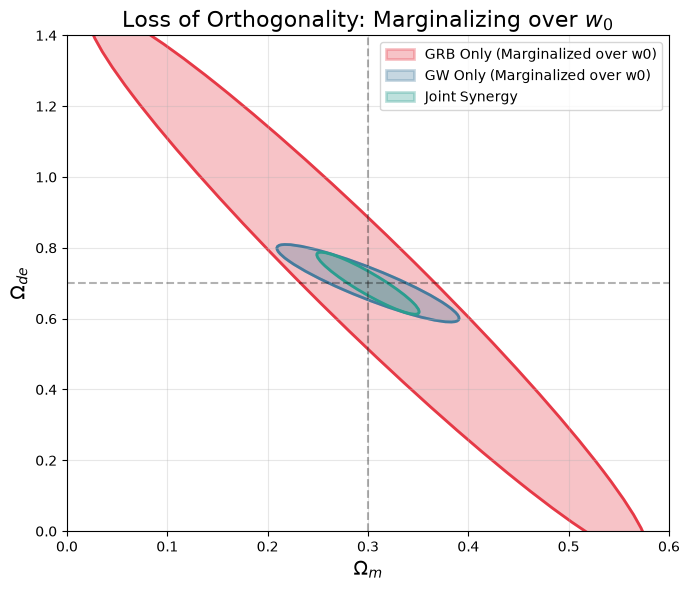

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def draw_marginalized_ellipse(ax, Cov_3x3, center, color, label):
    """Extracts the 2x2 marginalized Covariance matrix and plots it."""
    # Marginalize by simply extracting the top-left 2x2 block (Om, Ode)
    Cov_2x2 = Cov_3x3[0:2, 0:2]
    
    eigenvalues, eigenvectors = np.linalg.eigh(Cov_2x2)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(5.991 * eigenvalues) 
    
    ell = Ellipse(xy=center, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor=color, lw=2, alpha=0.3, label=label)
    ax.add_patch(ell)
    ax.add_patch(Ellipse(xy=center, width=width, height=height, angle=angle,
                         edgecolor=color, facecolor='none', lw=2))

# Fiducial Values
Om_true = 0.3
Ode_true = 0.7
# Parameter order for matrices: [Omega_m, Omega_de, w_0]

# --- Simulated 3D Fisher Matrices ---
# GWs: The w_0 uncertainty weakens the Om/Ode constraint slightly.
F_GW_3D = np.array([
    [8000, 6000, -2000], 
    [6000, 5000, -1500],
    [-2000, -1500, 1000]
])

# GRBs: In LambdaCDM, cross-terms with Ode are 0. With w_0 free, 
# dynamic DE grows at high-z, creating severe degeneracies across all 3 parameters.
F_GRB_3D = np.array([
    [12000, 1000,  8000], 
    [1000,   200,    400],
    [8000,   400,  6000]
])

F_Joint_3D = F_GW_3D + F_GRB_3D

# Invert Fisher Matrices to get 3x3 Covariance Matrices
C_GW_3D = np.linalg.inv(F_GW_3D)
C_GRB_3D = np.linalg.inv(F_GRB_3D)
C_Joint_3D = np.linalg.inv(F_Joint_3D)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(7, 6))
draw_marginalized_ellipse(ax, C_GRB_3D, (Om_true, Ode_true), '#e63946', 'GRB Only (Marginalized over w0)')
draw_marginalized_ellipse(ax, C_GW_3D, (Om_true, Ode_true), '#457b9d', 'GW Only (Marginalized over w0)')
draw_marginalized_ellipse(ax, C_Joint_3D, (Om_true, Ode_true), '#2a9d8f', 'Joint Synergy')

ax.set_xlim(0.0, 0.6)
ax.set_ylim(0.0, 1.4)
ax.set_xlabel(r'$\Omega_m$', fontsize=14)
ax.set_ylabel(r'$\Omega_{de}$', fontsize=14)
ax.set_title(r"Loss of Orthogonality: Marginalizing over $w_0$", fontsize=16)
ax.axvline(Om_true, color='k', ls='--', alpha=0.3)
ax.axhline(Ode_true, color='k', ls='--', alpha=0.3)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

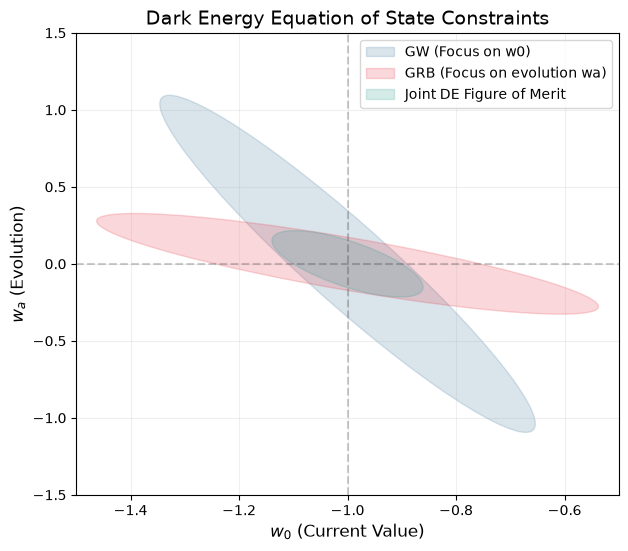

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Parameter order: [w0, wa]
# Fiducial: w0 = -1, wa = 0 (Standard Lambda)
center = [-1.0, 0.0]

# --- Simulated Fisher Matrices for w0-wa ---
# GWs: Tight on w0 (intercept), but wa (slope) is poorly constrained.
F_GW_w = np.array([[500, 150], 
                   [150, 50]])

# GRBs: Because they see 'past' DE, they are sensitive to the evolution (wa).
F_GRB_w = np.array([[100, 120], 
                    [120, 200]])

F_Joint_w = F_GW_w + F_GRB_w

fig, ax = plt.subplots(figsize=(7, 6))
# Using same plot_fisher logic as above
plot_fisher(ax, F_GW_w, center, '#457b9d', 'GW (Focus on w0)')
plot_fisher(ax, F_GRB_w, center, '#e63946', 'GRB (Focus on evolution wa)')
plot_fisher(ax, F_Joint_w, center, '#2a9d8f', 'Joint DE Figure of Merit')

ax.set_xlim(-1.5, -0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(r"$w_0$ (Current Value)", fontsize=12)
ax.set_ylabel(r"$w_a$ (Evolution)", fontsize=12)
ax.set_title("Dark Energy Equation of State Constraints", fontsize=14)
ax.axvline(-1, color='k', ls='--', alpha=0.2)
ax.axhline(0, color='k', ls='--', alpha=0.2)
ax.legend()
plt.grid(alpha=0.2)
plt.show()